In [49]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

In [25]:

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

def load_data(base_path):
    X = []
    Y = []

    for cls, label in classes.items():
        pth = os.path.join(base_path, cls)

        for filename in os.listdir(pth):
            img_path = os.path.join(pth, filename)

            img = cv2.imread(img_path, 0)
            if img is None:
                continue  # skip broken images

            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)
            Y.append(label)

    return np.array(X), np.array(Y)

In [26]:
# Split the dataset into training and testing sets
train_path = r"C:\\Users\\spiri\\Downloads\\Brain-Tumor-Detection-Using-SVM\\Training"
test_path  = r"C:\\Users\\spiri\\Downloads\\Brain-Tumor-Detection-Using-SVM\\Testing"

xtrain, ytrain = load_data(train_path)
xtest, ytest   = load_data(test_path)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier
#Rbf(default)
sv_rbf = SVC(kernel="rbf")
sv_rbf.fit(pca_train, ytrain)

#Linear
sv_linear = SVC(kernel="linear")
sv_linear.fit(pca_train, ytrain)

# Evaluate the default model
train_score_rbf = sv_rbf.score(pca_train, ytrain)
test_score_rbf = sv_rbf.score(pca_test, ytest)
print("Training Score Rbf:", train_score_rbf)
print("Testing Score Rbf:", test_score_rbf)

# Evaluate the Linear model
train_score_linear = sv_linear.score(pca_train, ytrain)
test_score_linear = sv_linear.score(pca_test, ytest)
print("Training Score linear:", train_score_linear)
print("Testing Score linear:", test_score_linear)

Training Score Rbf: 0.9689895470383275
Testing Score Rbf: 0.7182741116751269
Training Score linear: 1.0
Testing Score linear: 0.7360406091370558


In [33]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv_rbf.predict(pca.transform([img]))  # Predict using the trained SVM
        
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

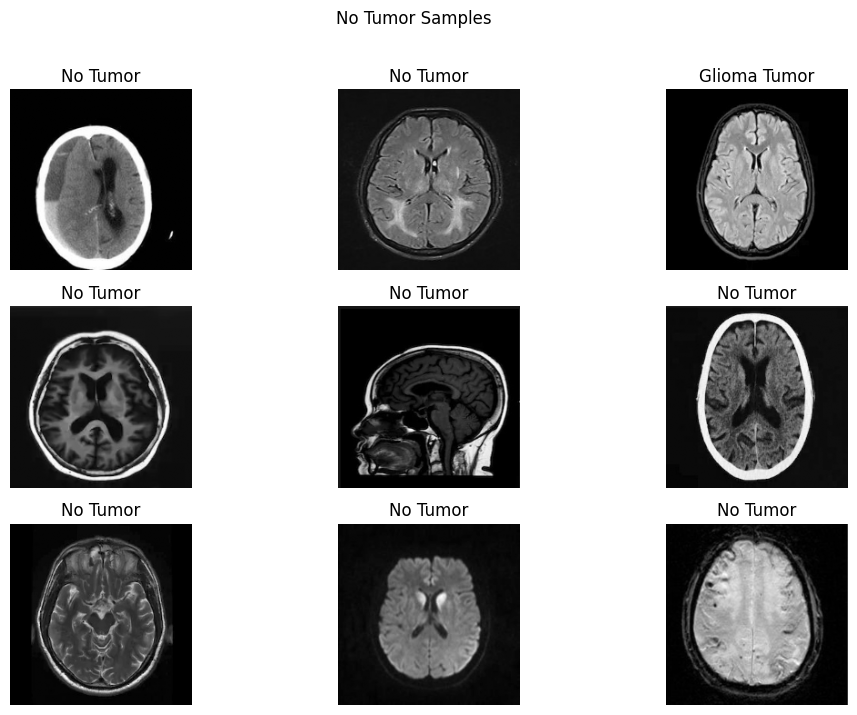

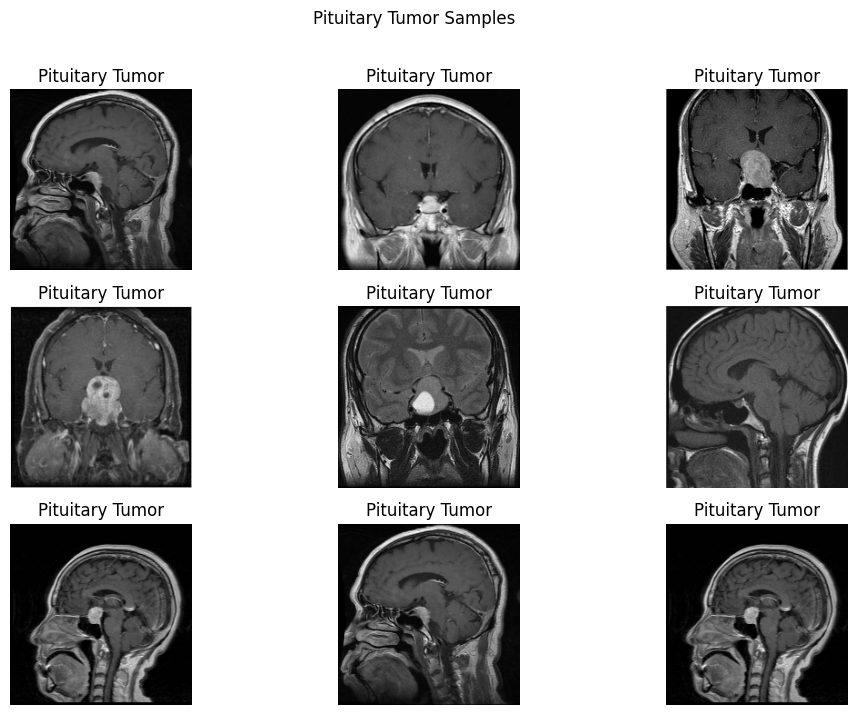

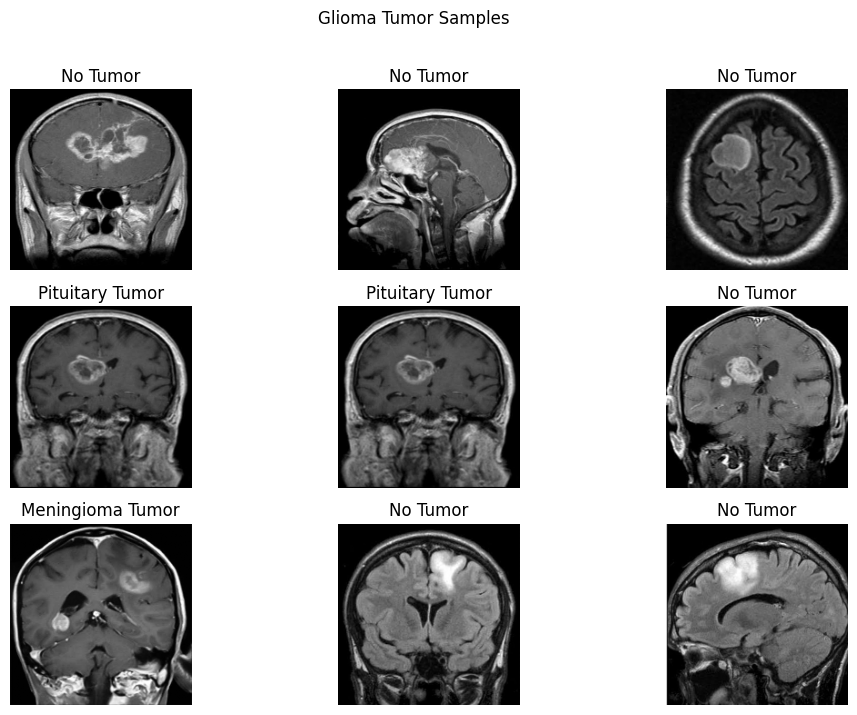

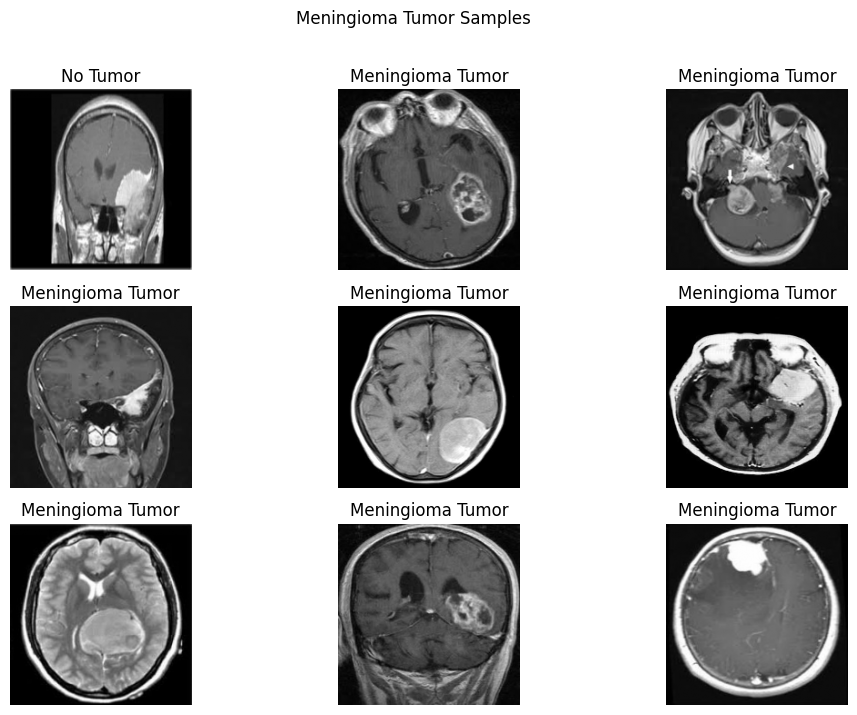

In [34]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}
# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = f"C:\\Users\\spiri\\Downloads\\Brain-Tumor-Detection-Using-SVM\\Testing\\{tumor_folder}"
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [35]:
# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m") 
display(styled_table)


Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


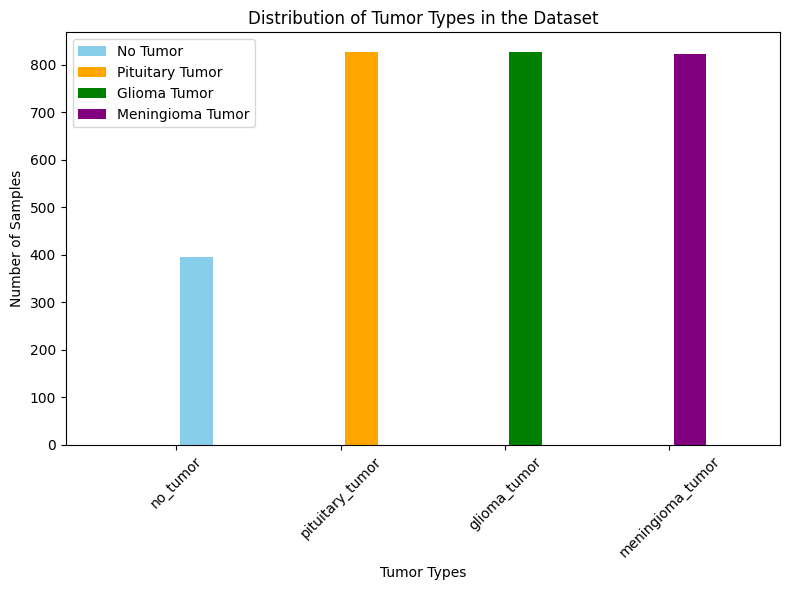

In [36]:

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show() 

In [48]:

# percentages
sizes = [0.2, 0.4, 0.6, 0.8]

rbf_acc = []
linear_acc = []

for s in sizes:
    # take subset of training data
    n = int(len(pca_train) * s)
    
    X_sub = pca_train[:n]
    y_sub = ytrain[:n]

    # RBF model
    model_rbf = SVC(kernel='rbf')
    model_rbf.fit(X_sub, y_sub)
    pred_rbf = model_rbf.predict(pca_test)
    rbf_acc.append(accuracy_score(ytest, pred_rbf))
    print(f"accuracy score of rbf for {s*100}% of data is:",accuracy_score(ytest, pred_rbf))

    # Linear model
    model_linear = SVC(kernel='linear')
    model_linear.fit(X_sub, y_sub)
    pred_linear = model_linear.predict(pca_test)
    linear_acc.append(accuracy_score(ytest, pred_linear))
    print(f"accuracy score of linear for {s*100}% of data is:",accuracy_score(ytest, pred_linear))

accuracy score of rbf for 20.0% of data is: 0.39593908629441626
accuracy score of linear for 20.0% of data is: 0.3883248730964467
accuracy score of rbf for 40.0% of data is: 0.4137055837563452
accuracy score of linear for 40.0% of data is: 0.4289340101522843
accuracy score of rbf for 60.0% of data is: 0.4517766497461929
accuracy score of linear for 60.0% of data is: 0.4796954314720812
accuracy score of rbf for 80.0% of data is: 0.550761421319797
accuracy score of linear for 80.0% of data is: 0.6091370558375635


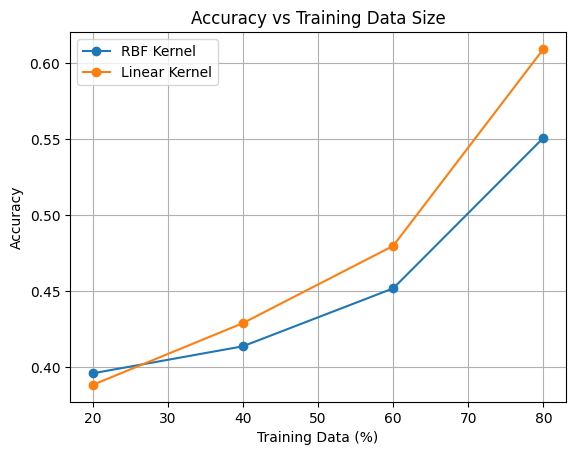

In [38]:
plt.plot([20, 40, 60, 80], rbf_acc, marker='o', label='RBF Kernel')
plt.plot([20, 40, 60, 80], linear_acc, marker='o', label='Linear Kernel')

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Data Size")
plt.legend()
plt.grid()

plt.show()

In [ ]:
ypred = sv_rbf.predict(pca_test)

# Accuracy
accuracy = accuracy_score(ytest, ypred)

# F1 Score 
f1 = f1_score(ytest, ypred, average='weighted')

# Sensitivity 
sensitivity = recall_score(ytest, ypred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(ytest, ypred)

specificity_list = []

for i in range(len(cm)):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

#printing the results
print("Results for rbf kernel")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Accuracy: 0.7182741116751269
F1 Score: 0.6839626831122175
Sensitivity (Recall): 0.7182741116751269
Specificity: 0.9043132611203875


In [ ]:
ypred = sv_linear.predict(pca_test)

# Accuracy
accuracy = accuracy_score(ytest, ypred)

# F1 Score 
f1 = f1_score(ytest, ypred, average='weighted')

# Sensitivity 
sensitivity = recall_score(ytest, ypred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(ytest, ypred)

specificity_list = []

for i in range(len(cm)):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

# Printing the results
print("Results for linear kernel")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Results for linear kernel
Accuracy: 0.7360406091370558
F1 Score: 0.6928118205449822
Sensitivity (Recall): 0.7360406091370558
Specificity: 0.9099626668741501
